In [ ]:
import numpy as np
import matplotlib.pyplot as plt

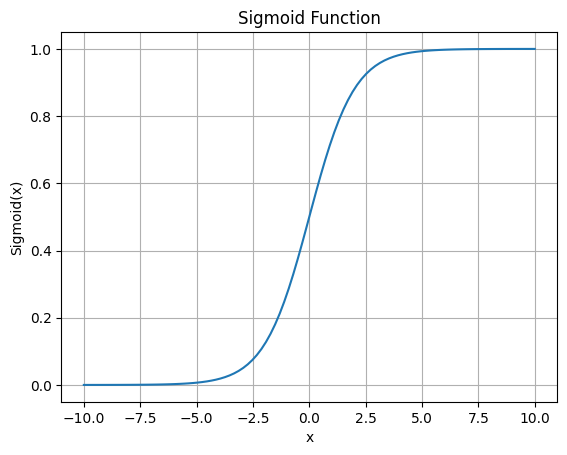

In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Generate input values
x = np.linspace(-10, 10, 100)

# Calculate sigmoid values
y = sigmoid(x)

# Plot the sigmoid function
plt.plot(x, y)
plt.title("Sigmoid Function")
plt.xlabel("x")
plt.ylabel("Sigmoid(x)")
plt.grid()
plt.show()

In [ ]:
print("Sigmoid(0):", sigmoid(0))  # Output: 0.5
print("Sigmoid(5):", sigmoid(5))  # Output: Close to 1
print("Sigmoid(-5):", sigmoid(-5))  # Output: Close to 0

Sigmoid(0): 0.5
Sigmoid(5): 0.9933071490757153
Sigmoid(-5): 0.0066928509242848554


Logistic regression uses log odds to transform linear outputs into probabilities.

	•	Log Odds Formula:

log-odds = beta_0 + beta_1 * x

	•	Logistic Function:

P(y=1|x) = 1/{1 + e^{-(beta_0 + beta_1 * x)}}


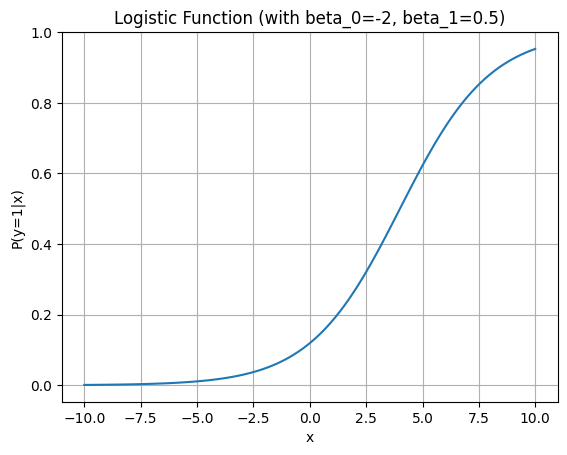

In [ ]:
# Logistic function
def logistic(x, beta_0, beta_1):
    log_odds = beta_0 + beta_1 * x
    return sigmoid(log_odds)

# Example coefficients
beta_0 = -2  # Intercept
beta_1 = 0.5  # Coefficient

# Generate input values
x = np.linspace(-10, 10, 100)
y = logistic(x, beta_0, beta_1)

# Plot the logistic function
plt.plot(x, y)
plt.title("Logistic Function (with beta_0=-2, beta_1=0.5)")
plt.xlabel("x")
plt.ylabel("P(y=1|x)")
plt.grid()
plt.show()

The decision boundary is the point where the probability is 0.5.

	•	For  beta_0 + beta_1 * x = 0 , the sigmoid function outputs 0.5.
	•	Solve for  x :

x = -{beta_0}/{beta_1}


In [ ]:
# Calculate the decision boundary
decision_boundary = -beta_0 / beta_1
print("Decision Boundary (x where P=0.5):", decision_boundary)

Decision Boundary (x where P=0.5): 4.0


	•	Odds: Ratio of the probability of success to failure:

text{Odds} = frac{P}/{1-P}

	•	Odds Ratio: Change in odds for a one-unit increase in  x .

In [ ]:
# Odds calculation
prob = 0.8  # Example probability
odds = prob / (1 - prob)
print("Odds for P=0.8:", odds)

Odds for P=0.8: 4.000000000000001


In [ ]:
# Logistic function for prediction
def predict_pass_or_fail(hours, beta_0, beta_1):
    prob = logistic(hours, beta_0, beta_1)
    return "Pass" if prob >= 0.5 else "Fail"

# Example: Predict outcomes for different hours of study
study_hours = [1, 2, 3, 4, 5]
predictions = [predict_pass_or_fail(h, beta_0=-2, beta_1=0.8) for h in study_hours]
print("Predictions:", predictions)

Predictions: ['Fail', 'Fail', 'Pass', 'Pass', 'Pass']


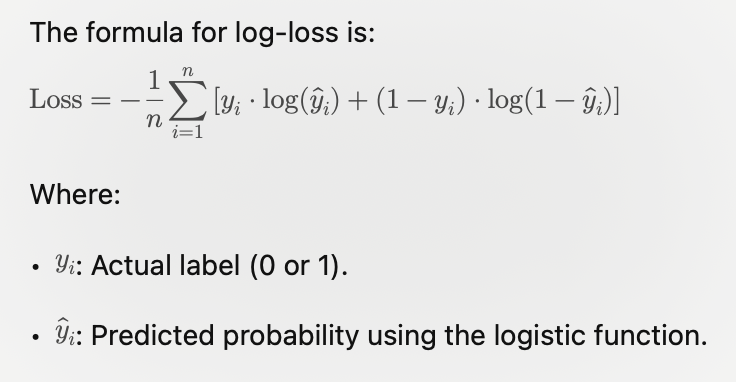

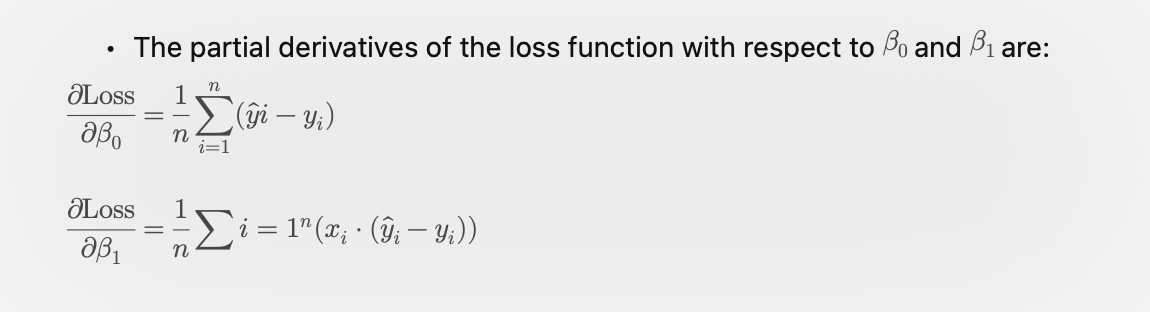

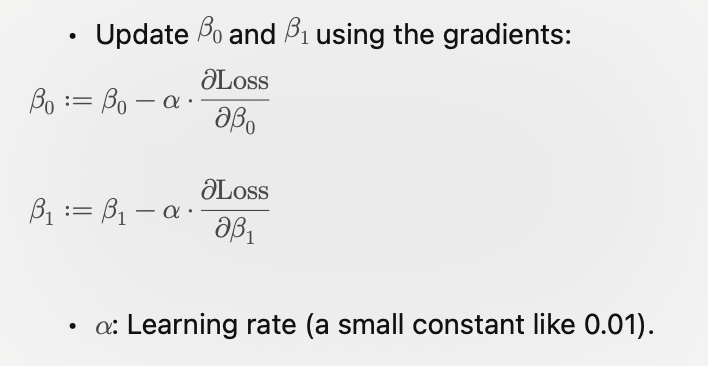

In [ ]:
import numpy as np

# Dataset: Feature (x) and labels (y)
x = np.array([1, 2, 3, 4, 5])  # Study hours
y = np.array([0, 0, 0, 1, 1])  # Pass or fail

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Logistic regression with gradient descent
def logistic_regression(x, y, learning_rate=0.01, iterations=1000):
    n = len(x)
    beta_0, beta_1 = 0.0, 0.0  # Initialize parameters

    for _ in range(iterations):
        # Compute predictions
        z = beta_0 + beta_1 * x
        predictions = sigmoid(z)

        # Compute gradients
        db0 = (1 / n) * np.sum(predictions - y)
        db1 = (1 / n) * np.sum((predictions - y) * x)

        # Update parameters
        beta_0 -= learning_rate * db0
        beta_1 -= learning_rate * db1

    return beta_0, beta_1

# Run gradient descent
beta_0, beta_1 = logistic_regression(x, y)
print("Estimated beta_0 (intercept):", beta_0)
print("Estimated beta_1 (coefficient):", beta_1)

Estimated beta_0 (intercept): -1.3725391953294654
Estimated beta_1 (coefficient): 0.4787135503233494


In [ ]:
# Predict probabilities
def predict_prob(x, beta_0, beta_1):
    return sigmoid(beta_0 + beta_1 * x)

# Predict classes
def predict_class(x, beta_0, beta_1):
    return [1 if prob >= 0.5 else 0 for prob in predict_prob(x, beta_0, beta_1)]

predictions = predict_class(x, beta_0, beta_1)
print("Predicted classes:", predictions)
print("Actual classes:", y.tolist())

Predicted classes: [0, 0, 1, 1, 1]
Actual classes: [0, 0, 0, 1, 1]


In [ ]:
from sklearn.linear_model import LogisticRegression

# Reshape x for sklearn
x_reshaped = x.reshape(-1, 1)

# Train logistic regression
model = LogisticRegression()
model.fit(x_reshaped, y)

print("Sklearn beta_0 (intercept):", model.intercept_[0])
print("Sklearn beta_1 (coefficient):", model.coef_[0][0])

Sklearn beta_0 (intercept): -3.7481774320466803
Sklearn beta_1 (coefficient): 1.0470438047457902
